# Homework №4 | Flow-map Models


In this homework, we distill a multi-step diffusion model into a few-step student model so that it runs an order of magnitude faster than the teacher. 

The main idea is to approximate the teacher PF-ODE solutions with a neural network (student), and use different integral properties to define diverse `flow-map` formulations.

In this assignment, you will implement **Consistency Distillation** and simplified **MeanFlow** setups for distilling the [`Stable Diffusion 1.5`](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5) (SD1.5) model for text-to-image generation into 4-step generator.

In [ ]:
# !pip install -U diffusers --upgrade

### [Stable Diffusion 1.5](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5)

**SD1.5** uses $\epsilon$-parameterization. 
To solve PF-ODE, we will use `DDIM`. For the VP process, the DDIM step from $t$ to $r$ is defined as follows:

$
x_r = \text{DDIM}(\mathbf{x}_t, t, r) = \alpha_r \cdot \left(\frac{\mathbf{x}_t - \sigma_t \epsilon_\theta}{\alpha_t} \right) + \sigma_r \epsilon_\theta
$

**SD1.5** consists of the following components:

1) **VAE** — maps $3{\times}512{\times}512$ images into $4{\times}64{\times}64$ latents.
2) **Text encoder** — extracts text features from text prompts.
3) **Diffusion model** — a UNet that operates on “latent images” of size $4{\times}64{\times}64$.

In [ ]:
from tqdm.auto import tqdm

import csv
import os
import torch
from PIL import Image
from diffusers import StableDiffusionPipeline, LCMScheduler, UNet2DConditionModel, DDIMScheduler

from peft import LoraConfig, get_peft_model, get_peft_model_state_dict

%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
#---------------------
# Visualization utils
#---------------------

def visualize_images(images):
    assert len(images) == 4
    plt.figure(figsize=(12, 3))
    for i, image in enumerate(images):
        plt.subplot(1, 4, i+1)
        plt.imshow(image)
        plt.axis('off')

    plt.subplots_adjust(wspace=-0.01, hspace=-0.01)


#--------------
# Tensor utils
#--------------

def extract_into_tensor(a, t, x_shape):
    b, *_ = t.shape
    out = a.gather(-1, t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

#---------------
# Dataset utils
#---------------

class TextImageDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, subset_name="train2014_5k", transform=None, max_cnt=None):
        """
        Arguments:
            root_dir (string): Директория с картинками
            transform (callable, optional): преобразования, применимые к картинкам
        """
        self.root_dir = root_dir
        self.transform = transform
        self.extensions = (
            ".jpg",
            ".jpeg",
            ".png",
            ".ppm",
            ".bmp",
            ".pgm",
            ".tif",
            ".tiff",
            ".webp",
        )
        sample_dir = os.path.join(root_dir, subset_name)

        # Собираем пути до картинок
        self.samples = sorted(
            [
                os.path.join(sample_dir, fname)
                for fname in os.listdir(sample_dir)
                if fname[-4:] in self.extensions
            ],
            key=lambda x: x.split("/")[-1].split(".")[0],
        )
        self.samples = (
            self.samples if max_cnt is None else self.samples[:max_cnt]
        )  #

        # Собираем промпты
        self.captions = {}
        with open(
            os.path.join(root_dir, f"{subset_name}.csv"), newline="\n"
        ) as csvfile:
            spamreader = csv.reader(csvfile, delimiter=",")
            for i, row in enumerate(spamreader):
                if i == 0:
                    continue
                self.captions[row[1]] = row[2]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        sample_path = self.samples[idx]
        sample = Image.open(sample_path).convert("RGB")

        if self.transform:
            sample = self.transform(sample)

        return {
            "image": sample,
            "text": self.captions[os.path.basename(sample_path)],
            "idxs": idx, }

## Preparation (1 pt)


### Teacher model

First, let's create the [StableDiffusion 1.5](https://huggingface.co/sd-legacy/stable-diffusion-v1-5) pipeline and generate images using 50 steps with the DDIM solver.

**Important:** for efficiency, load all components in FP16. Do not forget to put the model on GPU.

In [ ]:
pipe = <YOUR CODE HERE>

# Check that all model components are in FP16 and on cuda
assert pipe.unet.dtype == torch.float16 and pipe.unet.device.type == 'cuda'
assert pipe.vae.dtype == torch.float16 and pipe.vae.device.type == 'cuda'
assert pipe.text_encoder.dtype == torch.float16 and pipe.text_encoder.device.type == 'cuda'

# Replace the default solver with DDIM
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config, timestep_spacing="trailing")
pipe.scheduler.timesteps = pipe.scheduler.timesteps.cuda()
pipe.scheduler.alphas_cumprod = pipe.scheduler.alphas_cumprod.cuda()

# Define the teacher model that we plan to distill
teacher_unet = pipe.unet

Now, generate images using 50 steps. You need to write a pipe call and pass the prompt, the number of inference steps, a random number generator, the guidance scale, and specify that 4 images should be generated per prompt.

In [ ]:
prompt = "A sad puppy with large eyes"
guidance_scale = 7.5
generator = torch.Generator('cuda').manual_seed(1)

images = <YOUR CODE HERE>

visualize_images(images)

Let’s see what the model produces in 4 steps. Everything is the same as above; we just change the number of steps.

In [ ]:
generator = torch.Generator('cuda').manual_seed(1)

images = <YOUR CODE HERE>

visualize_images(images)

With 4 steps, the images come out blurry. Let’s try to improve them!

##  Creating the dataset

We will finetune the model on a small training set of 10,000 text-image pairs generated by the [FLUX](https://huggingface.co/black-forest-labs/FLUX.1-dev) model.

The data can be downloaded using the commands in the cell below. The current directory ./ should then contain:
* Folder flux_data with 10000 images
* File flux_data.csv with 10000 text prompts

The data is parsed correctly by the already implemented **TextImageDataset** class.

In [ ]:
!wget https://storage.yandexcloud.net/yandex-research/flux_data_10k.tar.gz
!tar -xzf flux_data_10k.tar.gz

**Important:** For faster debugging, you can use, e.g., 1000 images and run on a larger dataset only at the very end. Around 1000–2500 images should be sufficient to verify that the functions are implemented correctly. For initial debugging, you can use even fewer images.

**For the final run, it is sufficient to set `max_cnt=5000`**

In [ ]:
from torchvision import transforms

transform = transforms.Compose(
    [
        transforms.Resize(512),
        transforms.CenterCrop(512),
        transforms.ToTensor(),
        lambda x: 2 * x - 1,
    ]
)
dataset = TextImageDataset(".",
    subset_name="flux_data",
    transform=transform,
)

batch_size = 8 # Recommended batch size for Colab

train_dataloader = torch.utils.data.DataLoader(
    dataset=dataset, shuffle=True, batch_size=batch_size, drop_last=True
)

In [ ]:
@torch.no_grad()
def prepare_batch(batch, pipe):
    """
    Preprocessing a batch of images and text prompts
    Map the images into the VAE latent space.
    Extract prompt embeddings using the text encoder.

    Params:

    Return:
        latents: torch.Tensor([B, 4, 64, 64], dtype=torch.float16)
        prompt_embeds: torch.Tensor([B, 77, D], dtype=torch.float16)
    """

    # Tokenize text prompts
    text_inputs = pipe.tokenizer(
        batch['text'],
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )

    # Extract prompt embeddings using the text encoder
    prompt_embeds = pipe.text_encoder(text_inputs.input_ids.cuda())[0]

    # Map images into the VAE latent space
    image = batch['image'].to("cuda", dtype=torch.float16)
    latents = pipe.vae.encode(image).latent_dist.sample()
    latents = latents * pipe.vae.config.scaling_factor
    return latents, prompt_embeds

### Preparing the models and optimizer

First, we create the trainable student model: a UNet initialized with the SD1.5 weights. You should use the `UNet2DConditionModel` class and load **only** the UNet component from SD1.5.

Note that this model will be kept in full `FP32` precision, since training the parameters in `FP16` can lead to instability and lower quality.

In [ ]:
unet = <YOUR CODE HERE>

assert unet.dtype == torch.float32
assert unet.training

To reduce memory usage during training, we will train LoRA adapters with a small number of parameters.

LoRA is a lightweight modification to the model weights, where for a single weight matrix $W \in \mathbb{R}^{m \times n}$, two low-rank matrices are trained: $W_A \in \mathbb{R}^{k \times n}$ and $W_B \in \mathbb{R}^{k \times m}$, where $k$ is the rank and is much smaller than $m$ and $n$.

Thus, the updated weight matrix can be written as
$\hat{W} = W + \Delta W = W + W_B^T W_A$.

During inference, $\Delta W$ can be merged into $W$ to obtain the final model to avoid redundant calculations.
It is also common practice to keep unmerged adapters, allowing a single base model to support multiple adapters for different tasks and switch between them when needed.

If the adapters are not merged, the computations for the linear layer proceed as in the figure below.

<img src=https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/lora-idea.jpg width=300>

In [ ]:
# Setup the model layers to which LoRA is applied
lora_modules = [
    "to_q", "to_k", "to_v", "to_out.0", "proj_in", "proj_out",
    "ff.net.0.proj", "ff.net.2", "conv1", "conv2", "conv_shortcut",
    "downsamplers.0.conv", "upsamplers.0.conv", "time_emb_proj"
]
lora_config = LoraConfig(
    r=64, # Matrix rank for A and B in LoRA.
    lora_alpha=1, # controls a learning rate for LoRA training: lr_lora = lr_base * lora_alpha / r. If only LoRA parameters are being trained, you can simply adjust the learning rate in the optimizer.
    target_modules=lora_modules
)

# Create a wrapper around the original UNet model with LoRA adapters using the PEFT library
cm_unet = get_peft_model(unet, lora_config, adapter_name="cd")

# Enable gradient checkpointing - important technique for memory efficiency
cm_unet.enable_gradient_checkpointing()

# Create optimizer
optimizer = torch.optim.AdamW(cm_unet.parameters(), lr=2e-4)

###  Implement a DDIM step from $\mathbf{x}_t$ to $\mathbf{x}_s$

To complete the assignment correctly, you need to define $\alpha_t$ and $\sigma_t$ using `DDIMScheduler`.
**Pay attention to the attribute `scheduler.alphas_cumprod`**, which defines $\bar\alpha_t = \prod_{i=1}^{t} (1 - \beta_i)$ in the classical DDPM formulation: [Denoising Diffusion Probabilistic Models](https://arxiv.org/pdf/2006.11239).

In [ ]:
def ddim_solver_step(model_output, x_t, t, r, scheduler):
    """
    DDIM step for the VP process and epsilon model prediction 
    params:
        model_output: torch.Tensor[B, 4, 64, 64] - model prediction (epsilon) 
        x_t: torch.Tensor[B, 4, 64, 64] - noisy samples at t
        t: torch.Tensor[B] - current timestep
        r: torch.Tensor[B] - next timestep
        scheduler: DDIMScheduler - diffusion scheduler to access alphas_cumprod
    """
    alphas = <YOUR CODE HERE>
    sigmas = <YOUR CODE HERE>

    sigmas_r = extract_into_tensor(sigmas, r, x_t.shape)
    alphas_r = extract_into_tensor(alphas, r, x_t.shape)

    sigmas_t = extract_into_tensor(sigmas, t, x_t.shape)
    alphas_t = extract_into_tensor(alphas, t, x_t.shape)

    # Set the boundary values of alpha and sigma so that the boundary conditions are satisfied
    alphas_r[r == 0] = 1.0
    sigmas_r[r == 0] = 0.0

    alphas_t[t == 0] = 1.0
    sigmas_t[t == 0] = 0.0

    x_0 = <YOUR CODE HERE> # x0 estimate at t 
    x_r = <YOUR CODE HERE> # t --> r
    return x_r

###  Implement the forward process step

$q(\mathbf{x}_t | \mathbf{x}_0)= {N}(\mathbf{x}_t | \alpha_t \mathbf{x}_0, \sigma^2_t I)$

$\mathbf{x}_t = \alpha_t \mathbf{x}_0 + \sigma_t \epsilon$, где $\epsilon{\sim} {N}(0, I)$

In [ ]:
def q_sample(x, t, scheduler, noise=None):
    alphas = <YOUR CODE HERE>
    sigmas = <YOUR CODE HERE>

    if noise is None:
        noise = torch.randn_like(x)

    sigmas_t = extract_into_tensor(sigmas, t, x.shape)
    alphas_t = extract_into_tensor(alphas, t, x.shape)

    x_t = <YOUR CODE HERE>
    return x_t

## [Consistency Distillation](https://arxiv.org/pdf/2303.01469)

---

**Consistency Models (CM)** is a class of models where we aim to learn a `consistency function` $f_\theta(\mathbf{x}_t)$ that predicts $\mathbf{x}_0$ (clean data) from any point $\mathbf{x}_t$ on the diffusion ODE trajectory (2) in a single step.

If we learn the consistency function perfectly, we can move directly from pure noise to an image in one step, which is significantly more efficient than standard diffusion generation.

<br>

<div>

<img src="https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/cd-idea.jpg" width="600"/>
</div>


**Consistency Distillation (CD)** is an approach where a pretrained diffusion model is used to train a consistency model. The diffusion model provides a strong initialization and a learned score function, which significantly simplifies the training and convergence of consistency models.

---

#### Training CM

<div>
<img src="https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/cd-training.jpg" width="600"/>
</div>

The main idea of training consistency models is to enforce the `self-consistency` property: the outputs of the CM at two neighboring points on the trajectory, $\mathbf{x}_{t}$ and $\mathbf{x}_{t-1}$, should be close under some distance measure, for example the L2 distance:
$\lVert f_\theta(\mathbf{x}_{t-1}) - f_\theta(\mathbf{x}_{t}) \rVert_2^2$.

Note that the self-consistency property can be trivially satisfied without any training, for example by setting $f_\theta(\mathbf{x}_{t}) \equiv 0$.

Therefore, to avoid such degenerate solutions, we need to impose a `boundary condition` that enforces the model to reproduce the input at the leftmost point of the trajectory, near $t = 0$:
$f_\theta(\mathbf{x}_0) = \mathbf{x}_0$.

**Practical note:** The same model $f_\theta(\cdot)$ is applied to both points on the trajectory. However, the model output at step $t-1$ serves as the “target” for the output at step $t$, so the forward pass for step $t-1$ is performed in `torch.no_grad` mode.

---

**How do we obtain two neighboring points on the ODE trajectory?**

We take a random image $\mathbf{x}_0$ from the dataset.

The point $\mathbf{x}_t$ is obtained using the forward noising process:
$\mathbf{x}_t = q(\mathbf{x}_t \mid \mathbf{x}_0)$

To obtain the neighboring point $\mathbf{x}_{t-1}$, we need to take one step along the ODE trajectory using, for example, the DDIM solver.

For consistency distillation, we take a step with the pretrained diffusion model:
$\mathbf{x}_{t-1} = \text{DDIM}(\epsilon_\theta(\mathbf{x}_t, t), \mathbf{x}_t, t, t-1)$

**Important:** in practice, we do not use strictly adjacent steps $t$ and $t-1$; we can instead use some interval, e.g., `20 steps`. The interval size affects the bias-variance trade-off during training: a larger interval introduces more bias but lower variance, and vice versa.

For simplicity, in this assignment we fix the interval to `20 steps`, although in many papers the interval size changes dynamically during training.


## Training (4 pt)

Prepare the training procedure for consistency models. To do this, we will need to:

* Prepare a loss computation function,
* Build an efficient training loop.

**Note:** the functions below will be used extensively throughout the rest of the homework.

Below is a template for a function that computes the loss for consistency models.

**One more note:** the boundary condition to avoid the trivial solution should already be handled in `ddim_solver_step`

#### Implement the teacher step from $\mathbf{x}_t$ to $\mathbf{x}_s$

$\mathbf{x}_t = q(\mathbf{x}_t | \mathbf{x}_0)$

$\mathbf{x}_r = \text{DDIM}(\epsilon_\theta(\mathbf{x}_t, t), \mathbf{x}_t, t, r)$

**Important:** In text-to-image generation, `classifier-free guidance (CFG)` plays a crucial role. So, if it is important during inference, we should also distill CFG trajectories. Therefore, to obtain the point $\mathbf{x}_{r}$, we will use a teacher step with CFG.

In [ ]:
@torch.no_grad()
def get_xr_from_xt(
    x_t, t, r,
    scheduler,
    teacher_unet,
    prompt_embeds,
    guidance_scale=7.5,
    return_teacher_noise_pred=False,
    **kwargs
):
    # Conditional prediction with the teacher model
    cond_noise_pred = <YOUR CODE HERE>

    # For standard CFG, we need an unconditional prediction with the empty prompt ""
    # Extract empty prompt embeddings and expand them to the batch size
    uncond_prompt_embeds = <YOUR CODE HERE>

    # Unconditional prediction with the teacher model
    uncond_noise_pred = <YOUR CODE HERE>

    # Apply CFG
    noise_pred = <YOUR CODE HERE>

    # x_t --> x_r
    x_r = <YOUR CODE HERE>
    
    if return_teacher_noise_pred:
        # Useful for the MeanFlow implementation
        return x_r, noise_pred
    
    return x_r

#### Pseudo-Huber loss

As shown in the paper [Improved Techniques for Training Consistency Models](https://arxiv.org/pdf/2310.14189), the MSE loss is not the best choice for consistency models in practice and use the `Pseudo-Huber` loss.

**Note:** the loss definitions may differ between public implementations and the paper. The implementation from the paper is okay.

In [ ]:
def pseudo_huber_loss(
    x: torch.Tensor,
    y: torch.Tensor,
    c=0.001
):
    loss = <YOUR CODE HERE>
    return loss

In [ ]:
def cm_loss_template(
    latents, prompt_embeds,
    unet, teacher_unet, scheduler,

    get_boundary_timesteps: callable, # We will use different functions in CD and Multi-boundary CD

    num_timesteps=1000, 
    step_size=20, # Specifies the interval used to sample steps s and t.
):
    assert num_timesteps == 1000
    
    B = latents.shape[0]
    device = latents.device
    
    # Sample random timesteps t for each batch element: t ~ U[0, 999]
    t = <YOUR CODE HERE> # Starting timestep
    r = <YOUR CODE HERE> # Target timestep
    s = get_boundary_timesteps(
        r, num_timesteps=num_timesteps
    ) # Boundary timesteps | s = 0 for original CD

    # Sample the first PF-ODE point x_t
    noise = torch.randn_like(latents)
    x_t = <YOUR CODE HERE>

    # Predict with the "online" model 
    # with <YOUR CODE HERE>: # for mixed-precision training
    noise_pred = <YOUR CODE HERE>

    # Get boundary prediction for x_t (our predict)
    x_s_pred = <YOUR CODE HERE>

    # Obtain the second PF-ODE point x_r
    x_r = <YOUR CODE HERE>

    # Predict with the "target" model
    # with <YOUR CODE HERE>: # for mixed-precision training
    with torch.no_grad():
        target_noise_pred = <YOUR CODE HERE>

    # Get boundary prediction for x_r (our target)
    x_s_target = <YOUR CODE HERE>

    loss = pseudo_huber_loss(x_s_pred, x_s_target)
    return loss

In [ ]:
import functools

def get_zero_boundary_timesteps(t, **kwargs):
    """
    Defining the steps where boundary conditions apply.
    For classical CMs, this is t=0.
    """
    return torch.zeros_like(t)

cd_loss = functools.partial(
    cm_loss_template,
    get_boundary_timesteps=get_zero_boundary_timesteps,
)

assert cm_unet.active_adapter == 'cd'

### Training loop

You are given a training loop that trains the model in full precision (FP32) with a batch size of 8. Unfortunately, this will most likely not fit into the memory of a Tesla T4.

Therefore, in the cell below, you need to modify the training loop so that it runs in `mixed-precision FP16/FP32` and add `gradient accumulation`.

For details on implementing the mixed precision in PyTorch, you can follow this link: [Mixed-precision training](https://pytorch.org/docs/stable/notes/amp_examples.html#typical-mixed-precision-training)

**Note**: you will need to add one more line in *cm_loss_template* in the corresponding placeholder.

### Efficient training

This assignment is designed to be completed successfully in Colab using a free Tesla T4 with 15GB VRAM. However, training even relatively small text-to-image models at the SD1.5 scale naively in Colab is challenging.

To fit this memory budget and train in a reasonable amount of time, it is useful to apply a number of engineering techniques.

**Engineering techniques (Review)** 

1) Turn on **gradient checkpointing** for the trainable model
2) Add **LoRA** (Low Rank Adapters) adapters to train only 10% of the added weights
3) Use **gradient accumulation** to enable larger batch size updates by accumulating smaller batch gradients
4) Add **mixed precision FP16/FP32** for faster training. Typically, this also helps reduce memory usage, but in the case of LoRA training + gradient checkpointing, it should not significantly affect memory.
5) **Multi-GPU** training - distribute the batch across multiple GPUs.  

### What do we have in this assignment?

1-2) Already implemented

3 ) **Optional**. A batch size of 8 may already exceed the available memory, so you will likely need to implement gradient accumulation.

4 ) **Highly recommended for faster training**

5 ) Not the case for Colab


In [ ]:
# TODO: add mixed precision FP16/FP32

def train_loop(model, teacher_unet, pipe, train_dataloader, optimizer, loss_fn, num_grad_accum=1, max_iters=-1):
    torch.cuda.empty_cache()

    for i, batch in enumerate(tqdm(train_dataloader)):

        optimizer.zero_grad(set_to_none=True)

        latents, prompt_embeds = prepare_batch(batch, pipe)

        loss = loss_fn(latents, prompt_embeds, model, teacher_unet, pipe.scheduler)

        loss.backward()
        optimizer.step()
        
        if max_iters == i:
            break

        print(f"Loss: {loss.detach().item()}")

In [ ]:
num_grad_accum = 2 # Update parameters each 2 steps (if needed)

# ~100-200 iterations are sufficient for debugging
# For the final run, you can take 400 or more iters.
# Note that the loss may be uninformative and may even increase. My loss values were in the range 0.02-0.08 but it may depend on your pseudo-huber loss implementation.
train_loop(cm_unet, teacher_unet, pipe, train_dataloader, optimizer, cd_loss, num_grad_accum, max_iters=400)

## Sampling with Consistency Models (3 pt)

Recall that we cannot use DDIM or other classical diffusion solvers for consistency models.

We need a special sampler for CMs, which is schematically illustrated in the figure below:

<div>
<img src="https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/cd-sampling-idea.jpg" width="600"/>
</div>

More formally:

$x_{t_n} \sim {N}(0, I)$

$for\ t_i \in [t_n, ..., t_1]:$

* $\epsilon \leftarrow unet(x_{t_i})$

* $x_0 \leftarrow \text{DDIM}(\epsilon, x_{t_i}, t_i, 0)$

* $x_{t_{i-1}} \leftarrow q(x_{t_{i-1}} | x_0)$


**Note:** `Classifier-free guidance (CFG)` is already "distilled" into the CD model as the student is trained to approximate the teacher ODE trajectories with CFG.

In [ ]:
@torch.no_grad()
def consistency_sampling(
    pipe,
    prompt,
    num_inference_steps=4,
    generator=None,
    num_images_per_prompt=4,
):
    if prompt is not None and isinstance(prompt, str):
        batch_size = 1
    elif prompt is not None and isinstance(prompt, list):
        batch_size = len(prompt)

    device = pipe._execution_device

    # Extract prompt embeddings using pipe.encode_prompt
    prompt_embeds = <YOUR CODE HERE>
    assert prompt_embeds.dtype == torch.float16

    # Setup the few step scheduler
    assert pipe.scheduler.config['timestep_spacing'] == 'trailing'
    pipe.scheduler.set_timesteps(num_inference_steps)

    # Create a latent batch N(0,I) of the appropriate shape
    latents = <YOUR CODE HERE>

    # Sampling loop
    <YOUR CODE HERE>

    # Decode latents into pixels. Do not forget to rescale the latents using pipe.vae.config.scaling_factor 
    image = <YOUR CODE HERE>
    do_denormalize = [True] * image.shape[0]
    image = pipe.image_processor.postprocess(image, output_type="pil", do_denormalize=do_denormalize)
    return image

Let’s try to generate something with our model. For reference, we provide example images at this stage:

![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/reference-cd.png)

**Your images do not have to match exactly; they may be slightly lower or higher in quality.**

In [ ]:
pipe.unet = cm_unet.eval().to(torch.float16)
assert cm_unet.active_adapter == 'cd'

generator = torch.Generator(device="cuda").manual_seed(0)

# Replace pipeline sampling with your sampling function
images = <YOUR CODE HERE>

visualize_images(images)

#### Let’s take a look at the images for other prompts


In [ ]:
validation_prompts = [
    "A sad puppy with large eyes",
    "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k",
    "A photo of beautiful mountain with realistic sunset and blue lake, highly detailed, masterpiece",
    "A girl with pale blue hair and a cami tank top",
    "A lighthouse in a giant wave, origami style",
    "belle epoque, christmas, red house in the forest, photo realistic, 8k",
    "A small cactus with a happy face in the Sahara desert",
    "Green commercial building with refrigerator and refrigeration units outside",
]

for prompt in validation_prompts:
    generator = torch.Generator(device="cuda").manual_seed(0)

    images = <YOUR CODE HERE>

    visualize_images(images)

## Multi-boundary Сonsistency Distillation (1 pt)

---

<div>
<img src=https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/multi-cd-idea.jpg width=600>
<div> <br>
    
    
Now we consider the recent modification of CD, **Multi-boundary CD**, where instead of integrating over the entire trajectory at once and then sampling back and forth, we split the trajectory into $K$ segments and apply CD independently within each segment. For example, in the figure above, there are two segments: the green and red regions correspond to two boundary points.

For classical CD, discussed earlier, there is only one boundary point at $t = 0$.

Note that sampling becomes deterministic, allowing us to reuse the **DDIM solver**, where the number of steps equals the number of intervals $K$ used to split the trajectory during training.

This method works significantly better than standard CD because solving CD on smaller segments is much easier than over the entire trajectory. In this assignment, we will split the trajectory into $K=4$ segments.

For more details, see this [paper](https://arxiv.org/pdf/2403.06807).

---

Implement the function below so that, for $K=4$ segments, it maps each timestep to its corresponding boundary timestep.

For example, for $K=2$ segments, the boundary timesteps will be: [0, 499]

$0 \leq t < 499$ -> boundary timestep: $0$

$499 \leq t < 999$ -> boundary timestep: $499$

**Note:** remember that the interval between $t$ and $s$ is 20 steps.


In [ ]:
def get_multi_boundary_timesteps(
    timesteps,
    num_boundaries=4,
    num_timesteps=1000,
):
    """
    For a batch of timesteps, determine the corresponding boundary points.
    params:
        timesteps: torch.Tensor(batch_size, device='cuda')
    returns:
        boundary_timesteps: torch.Tensor(batch_size, device='cuda')
    """
    # Note: It is important to print timesteps and boundary_timesteps before training 
    # to ensure that the boundary points are not overstepped, while still being hit sometimes.
    
    <YOUR CODE HERE>
    return boundary_timesteps

In [ ]:
# Add new LoRA adapters for the multi-CD model
cm_unet.add_adapter("multi-cd", lora_config)
cm_unet.set_adapter("multi-cd")

# Create a new optimizer
optimizer = torch.optim.AdamW(cm_unet.parameters(), lr=2e-4)

In [ ]:
multi_cd_loss = functools.partial(
    cm_loss_template,
    get_boundary_timesteps=get_multi_boundary_timesteps,
)
assert cm_unet.active_adapter == 'multi-cd'

### Training the Multi-boundary CD model

In [ ]:
num_grad_accum = 2 # update parameters each two steps (if needed)

# ~100-200 iterations are sufficient for debugging
# For the final run, you can take 400 or more iters.
train_loop(cm_unet, teacher_unet, pipe, train_dataloader, optimizer, multi_cd_loss, num_grad_accum, max_iters=400)

### Sampling one more time

**Important: Stochastic sampling is no longer suitable here, but we now can sample deterministically using the original DDIM solver with 4 steps.**

Below, we provide a reference, and note that your images may differ and may be slightly worse or better.
![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/reference-multi-cd.png)

In [ ]:
pipe.unet = cm_unet.eval().to(torch.float16)
assert cm_unet.active_adapter == 'multi-cd'

guidance_scale = 1 # No CFG setup

for prompt in validation_prompts:
    generator = torch.Generator(device="cuda").manual_seed(1)

    images = <YOUR CODE HERE>

    visualize_images(images)

## [MeanFlow](https://arxiv.org/abs/2505.13447) (1pt + 2 pt bonus)

Finally, let's consider the MeanFlow model in a simplified distillation setting. Recall the idea.

1) We worked in the flow matching setup:
$ \dot{\mathbf{x}}_{s} = v(\mathbf{x}_{s}, s) \rightarrow \mathbf{x}_{s} = \mathbf{x}_{t} - \int_{s}^{t} v(\mathbf{x}_{\tau}, \tau),\mathrm{d}\tau $

2) We defined the mean velocity as
$ u(\mathbf{x}_{t}, s, t) := \frac{1}{(t-s)} \cdot \int_{s}^{t} v(\mathbf{x}_{\tau}, \tau),\mathrm{d}\tau $, where we move from t to s
3) We took the derivative of the mean velocity and obtained `MeanFlow Identity`:
$ u(\mathbf{x}_{t}, s, t) = v(\mathbf{x}_{t}, t) - (t-s)\frac{\mathrm{d}}{\mathrm{d}t}u(\mathbf{x}_{t}, s, t)$

4) We used this expression to obtain the following loss:

$\mathcal{L}^{\text{MF}}_{\theta} = \|u_{\theta}(\mathbf{x}_{t}, s, t) - stopgrad\left[v(\mathbf{x}_{t}, t) - (t-s)\frac{\mathrm{d}}{\mathrm{d}t}u(\mathbf{x}_{t}, s, t)\right] \|^2_2$

**In this homework, we consider MeanFlow in a simplified setting:**

* We distill a model rather than train it from scratch.
* We approximate $\frac{\mathrm d}{\mathrm dt}u_{\theta}(\mathbf{x}_{t}, t, s)$ numerically in order to avoid JVP.
* Instead of arbitrary end points $s$, we use fixed boundary timesteps. Suppose we split the time interval into 4 parts and step only to the fixed timesteps. In this case, the model resembles the previous multi-boundary CD setup.

**You will need to do the following:**

* Reparameterize $\epsilon$-prediction to $v$-prediction for the VP process
* Reparameterize the loss in terms of the mean velocity $u$. **Hint:** use the $\text{DDIM}$ step and then derive the mean velocity given two points on the PF-ODE trajectory. 
* Compute the derivative as $\frac{\mathrm d}{\mathrm dt}u_{\theta}(\mathbf{x}_{t}, s, t) \approx \frac{u_{\theta}(\mathbf{x}_{t}, s, t) - u_{\theta}(\mathbf{x}_{r}, s, r)}{t - r}$

As you can see, we need to obtain the point $\mathbf{x}_{r}$ for the approximation.

### Implement reparameterization from $\epsilon$- to $v$-prediction in VP (1 pt)

In general Flow Matching, we have $v_t = \dot{\mathbf{x}_t}$. 

You need to derive $v_t$ for the VP process and implement $v_t$ for the VP process.

**< YOUR DERIVATION >**

In [ ]:
def epsilon_to_v(model_output, x_t, t, scheduler):
    """
    Reparameterize eps-prediction to v in the VP case as discussed above 
    """
    
    <YOUR CODE HERE>
    return v

### [Bonus] Implement MeanFlow loss (2 pt)

In [ ]:
def meanflow_loss_template(
    latents,
    prompt_embeds,
    unet,
    teacher_unet,
    scheduler,

    get_boundary_timesteps,

    num_timesteps=1000,
    step_size=1,
):
    """
    Some parts of cm_loss_template can be reused here.
    """
    assert num_timesteps == 1000

    B = latents.shape[0]
    device = latents.device

    # Sample timesteps
    t = <YOUR CODE HERE> # Starting timestep
    r = <YOUR CODE HERE> # Intermediate timestep to estimate the derivative
    s = get_boundary_timesteps(r, num_timesteps=num_timesteps) # Boundary timesteps

    # Sample x_t
    noise = torch.randn_like(latents)
    x_t = <YOUR CODE HERE>
    
    # Model prediction
    # --------------------------------------------------------

    # Noise predictition at the point x_t using student
    # with <YOUR CODE HERE>: # for mixed-precision training
    noise_pred_t = <YOUR CODE HERE>

    # Get boundary prediction for x_t
    x_s_from_t = <YOUR CODE HERE>
    
    # Derive averaged velocity using x_t and x_s_from_t
    u_s_t = <YOUR CODE HERE>
    # --------------------------------------------------------

    # Compute target
    # --------------------------------------------------------
    with torch.no_grad():

        # Transition from x_t to x_r (use the teacher)
        x_r, eps_target = <YOUR CODE HERE>
        v_target = epsilon_to_v(eps_target, x_t, t, scheduler)

        # Approximate the du_dt
        
        # Noise predictition at the point x_r using student
        # with <YOUR CODE HERE>: # for mixed-precision training
        noise_pred_r = <YOUR CODE HERE>
        
        # Get boundary prediction for x_r
        x_s_from_r = <YOUR CODE HERE>
        
        # Derive averaged velocity using x_r and x_s_from_r
        u_s_r = <YOUR CODE HERE>
        
        # Estimate the derivative
        du_dt = <YOUR CODE HERE>

        # Compute the final target
        u_target = <YOUR CODE HERE>
    # --------------------------------------------------------

    loss = pseudo_huber_loss(u_s_t, u_target)
    return loss

In [ ]:
# Add new LoRA adapters for the MeanFlow model
cm_unet.add_adapter("meanflow", lora_config)
cm_unet.set_adapter("meanflow")

# Create a new optimizer
optimizer = torch.optim.AdamW(cm_unet.parameters(), lr=1e-3)

In [ ]:
meanflow_loss = functools.partial(
    meanflow_loss_template,
    step_size=1,
    get_boundary_timesteps=get_multi_boundary_timesteps,
)
assert cm_unet.active_adapter == 'meanflow'

In [ ]:
num_grad_accum = 2 # update parameters each two steps

train_loop(cm_unet, teacher_unet, pipe, train_dataloader, optimizer, meanflow_loss, num_grad_accum)

If you get something like this at intermediate steps (~200), it may indicate that the model has not converged yet, but is moving in the right direction.

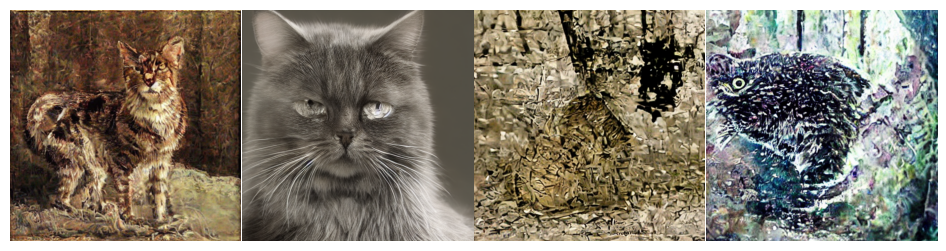

In [ ]:
pipe.unet = cm_unet.eval().to(torch.float16)
assert cm_unet.active_adapter == 'meanflow'

guidance_scale = 1 # No CFG setup

for prompt in validation_prompts:
    generator = torch.Generator(device="cuda").manual_seed(1)

    # For meanflow, we can also use the deterministic pipeline sampling
    images = <YOUR CODE HERE>

    visualize_images(images)

**That's it! Congrats!**

<div>
<img src="https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/yoda.jpg" width=400>
<div>

### P.S. Several examples of the potentially bad genetation results 

#### Incorrect sampling

![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/fail_case_1.jpg)
![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/fail_case_2.jpg)

#### Training mistakes

![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/fail_case_3.jpg)
![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/fail_case_4.jpg)

#### underfitted model

![img](https://storage.yandexcloud.net/yandex-research/cvweek-cd-task-images/fail_case_5.jpg)
